In [14]:
import pandas as pd
import numpy as np
import json
import joblib
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [12]:
# Load data from JSON file (array of objects)
with open('data-sample.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

# If your JSON is an array, not an object with "data" key:
df = pd.DataFrame(data)
# If label is boolean, you may want to convert it to int or str
df['label'] = df['label'].astype(int)  # Uncomment if needed

X = df['text']
y = df['label']

# show head
print(df.head())

                                                text  label
0                        mari ramai ernia widyatmoko      0
1         mantap linkbonbon berani kasi menang orang      1
2  wd coy mahaslot royal bro jt kasih nya hahah m...      1
3                     gacor parah ey mantap mahaslot      1
4  wajah materialistis udah klaim freebet pepe kl...      1


In [16]:
# Stratified K-Fold Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
all_y_true = []
all_y_pred = []
cv_scores = []

for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    vectorizer = TfidfVectorizer(max_features=5000)
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)
    
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    cv_scores.append(accuracy_score(y_test, y_pred))

print("Stratified 5-Fold CV Accuracy scores:", cv_scores)
print("Mean Accuracy:", np.mean(cv_scores))
print("\nClassification Report:\n", classification_report(all_y_true, all_y_pred))
print("Confusion Matrix:\n", confusion_matrix(all_y_true, all_y_pred))

# Optionally, train on all data for deployment
# vectorizer = TfidfVectorizer(max_features=5000)
# X_tfidf = vectorizer.fit_transform(X)
# model = RandomForestClassifier(n_estimators=100, random_state=42)
# model.fit(X_tfidf, y)

# Save the model and vectorizer for future use
# joblib.dump(model, 'rf_model.pkl')
# joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

Stratified 5-Fold CV Accuracy scores: [0.96, 0.9671428571428572, 0.9528571428571428, 0.9714285714285714, 0.9757142857142858]
Mean Accuracy: 0.9654285714285715

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.91      0.91       649
           1       0.98      0.98      0.98      2851

    accuracy                           0.97      3500
   macro avg       0.94      0.95      0.94      3500
weighted avg       0.97      0.97      0.97      3500

Confusion Matrix:
 [[ 593   56]
 [  65 2786]]


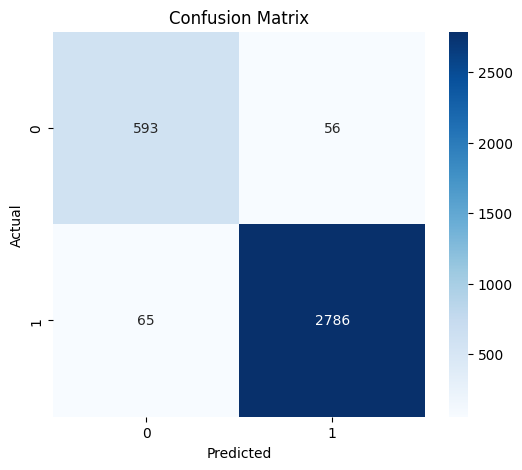

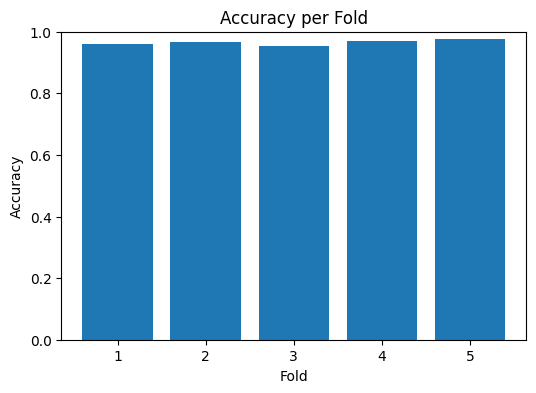

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# ...existing code...

# After printing the confusion matrix and classification report:
cm = confusion_matrix(all_y_true, all_y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Accuracy scores bar plot
plt.figure(figsize=(6, 4))
plt.bar(range(1, len(cv_scores) + 1), cv_scores)
plt.ylim(0, 1)
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Accuracy per Fold')
plt.show()